# SAJU ML Candidate Validation V1.4

## Goal

V1.3 found two serious Career candidates:

- **TENGOD**: small, stable feature set
- **SHINSAL**: surprisingly strong, but much higher-dimensional and therefore more suspicious

This notebook does **not** add new astrology concepts.

It answers:

1. Does TENGOD survive repeated subject CV, LOSO, permutation, and paired bootstrap?
2. Does SHINSAL survive the same tests?
3. Which Shinsal sub-family actually carries the signal?
4. Are the learned coefficients stable when one person is removed?
5. Which candidate is worth freezing before expanding the corpus?

## Hard boundaries

- Development corpus only
- Career only
- No Validation B
- No Public CHECK
- No Public FINAL
- Pairwise Logistic Regression only
- Fixed `C=0.3`
- No hyperparameter search
- No model-family sweep
- No hand-picked coefficient signs

## Expected directory

```text
saju/
├── saju_engine.py
└── research/
    ├── ml_corpus/
    │   └── v1/
    │       └── SAJU_ML_CORPUS_V1.json
    └── ml/
        ├── saju_ml_research_v1.ipynb
        ├── saju_ml_feature_sweep_v1_3.ipynb
        ├── saju_ml_candidate_validation_v1_4.ipynb
        └── artifacts/
            ├── v1/
            │   └── ml_feature_table_v1.parquet OR .csv
            ├── v1_3/
            │   └── extended_astrology_features_v1_3.csv
            └── v1_4/
```

Run V1 and V1.3 first. V1.4 reuses their cached features, so it does not need to recompute the saju engine.

In [1]:
from pathlib import Path
from itertools import product
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 20260815
TARGET_DOMAIN = "Career"

N_REPEATS = 100
N_FOLDS = 5
N_PERMUTATIONS = 500
N_BOOTSTRAP = 20000

STRICT_BIRTH_TIME = True

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "saju_engine.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find repo root containing saju_engine.py. "
        "Run this notebook from inside the Chartpalja saju repo."
    )

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "research" / "ml_corpus" / "v1"
V1_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1"
V13_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1_3"
ARTIFACT_DIR = REPO_ROOT / "research" / "ml" / "artifacts" / "v1_4"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT)
print("V1 artifacts:", V1_DIR)
print("V1.3 artifacts:", V13_DIR)
print("V1.4 output:", ARTIFACT_DIR)

repo: /Users/sangjinlee/Desktop/projects/saju
V1 artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1
V1.3 artifacts: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1_3
V1.4 output: /Users/sangjinlee/Desktop/projects/saju/research/ml/artifacts/v1_4


## 1. Load the exact V1 corpus and cached features

In [2]:
corpus = json.load(open(DATA_DIR / "SAJU_ML_CORPUS_V1.json", encoding="utf-8"))

v1_pq = V1_DIR / "ml_feature_table_v1.parquet"
v1_csv = V1_DIR / "ml_feature_table_v1.csv"
v13_ext = V13_DIR / "extended_astrology_features_v1_3.csv"

if v1_pq.exists():
    v1_features = pd.read_parquet(v1_pq)
elif v1_csv.exists():
    v1_features = pd.read_csv(v1_csv)
else:
    raise FileNotFoundError("Run saju_ml_research_v1.ipynb first.")

if not v13_ext.exists():
    raise FileNotFoundError(
        "extended_astrology_features_v1_3.csv not found. "
        "Run saju_ml_feature_sweep_v1_3.ipynb first."
    )

extended_features = pd.read_csv(v13_ext)

assert corpus["source_pools"] == {"OLD_DEV": 56, "FRESH_A": 14, "PUBLIC_DEV": 24}
assert all(
    s["source_pool"] not in {"VALIDATION_B", "PUBLIC_CHECK", "PUBLIC_FINAL"}
    for s in corpus["subjects"]
)

print("corpus subjects:", len(corpus["subjects"]))
print("V1 feature rows:", len(v1_features))
print("V1.3 extended rows:", len(extended_features))

corpus subjects: 94
V1 feature rows: 341
V1.3 extended rows: 113


## 2. Rebuild Career labels exactly as before

- unknown is excluded
- conflicting positive+negative labels in the same subject-year are excluded
- only subjects with at least one positive and one negative Career year are pair-evaluable

In [3]:
def build_target_rows(domain):
    raw = []

    for s in corpus["subjects"]:
        if STRICT_BIRTH_TIME and not s["birth"]["birth_time_known"]:
            continue

        for e in s["events"]:
            if not e["ml_usable"]:
                continue

            lab = e["targets"].get(domain, "unknown")
            if lab not in {"positive", "negative"}:
                continue

            raw.append({
                "subject_id": s["subject_id"],
                "name": s["name"],
                "source_pool": s["source_pool"],
                "year": int(e["year"]),
                "label": 1 if lab == "positive" else 0,
                "event_id": e["event_id"],
            })

    raw_df = pd.DataFrame(raw)
    rows, collisions = [], []

    for (sid, year), g in raw_df.groupby(["subject_id", "year"]):
        if g["label"].nunique() > 1:
            collisions.append({
                "subject_id": sid,
                "year": int(year),
                "event_ids": list(g["event_id"]),
            })
            continue

        rows.append({
            "subject_id": sid,
            "name": g["name"].iloc[0],
            "source_pool": g["source_pool"].iloc[0],
            "year": int(year),
            "label": int(g["label"].iloc[0]),
        })

    return pd.DataFrame(rows), pd.DataFrame(collisions)

target_rows, collisions = build_target_rows(TARGET_DOMAIN)

pairable = []
for sid, g in target_rows.groupby("subject_id"):
    if set(g["label"]) == {0, 1}:
        pairable.append(sid)

target_rows = target_rows[target_rows["subject_id"].isin(pairable)].copy()

model_df = (
    target_rows
    .merge(v1_features, on=["subject_id", "year"], how="inner", validate="one_to_one")
    .merge(extended_features, on=["subject_id", "year"], how="inner", validate="one_to_one")
)

print("Career rows:", len(model_df))
print("pair-evaluable subjects:", model_df["subject_id"].nunique())
print("positive / negative:",
      int(model_df["label"].sum()),
      int((1 - model_df["label"]).sum()))
print("colliding years excluded:", len(collisions))

Career rows: 113
pair-evaluable subjects: 23
positive / negative: 75 38
colliding years excluded: 2


## 3. Freeze candidate feature families

### Candidate A: TENGOD

Only the 10 V1 variables:

- Daewoon five-group Ten-God
- Sewoon five-group Ten-God

### Candidate B: SHINSAL

Use the V1.3 engine-derived Shinsal block, but also decompose it into:

- **GONGMANG**
- **NOBLE**
- **SCALAR**
- **OTHER**

This checks whether the 43-feature SHINSAL result is a broad signal or one narrow engine field.

In [4]:
def nonconstant(cols):
    out = []
    for c in cols:
        if c in model_df.columns and model_df[c].nunique(dropna=False) > 1:
            out.append(c)
    return sorted(out)

tengod = nonconstant([
    c for c in model_df.columns
    if c.startswith("tengod__")
])

shinsal_all = nonconstant([
    c for c in model_df.columns
    if c.startswith("shinsal__")
])

shinsal_gongmang = nonconstant([
    c for c in shinsal_all
    if "gongmang" in c.lower() or "공망" in c
])

shinsal_noble = nonconstant([
    c for c in shinsal_all
    if (
        "noble" in c.lower()
        or "귀인" in c
        or "guiren" in c.lower()
    )
])

shinsal_scalar = nonconstant([
    c for c in shinsal_all
    if (
        "scalar" in c.lower()
        or "breakdown" in c.lower()
    )
])

used_special = set(shinsal_gongmang + shinsal_noble + shinsal_scalar)
shinsal_other = nonconstant([
    c for c in shinsal_all
    if c not in used_special
])

FEATURE_SETS = {
    "TENGOD": tengod,
    "SHINSAL_ALL": shinsal_all,
}

for name, cols in [
    ("SHINSAL_GONGMANG", shinsal_gongmang),
    ("SHINSAL_NOBLE", shinsal_noble),
    ("SHINSAL_SCALAR", shinsal_scalar),
    ("SHINSAL_OTHER", shinsal_other),
]:
    if cols:
        FEATURE_SETS[name] = cols

print("feature counts")
for k, v in FEATURE_SETS.items():
    print(f"{k:20s}: {len(v)}")

assert len(tengod) > 0
assert len(shinsal_all) > 0

feature counts
TENGOD              : 10
SHINSAL_ALL         : 43
SHINSAL_GONGMANG    : 5
SHINSAL_NOBLE       : 7
SHINSAL_SCALAR      : 1
SHINSAL_OTHER       : 30


## 4. Feature coverage audit

In [5]:
coverage_rows = []

for family, cols in FEATURE_SETS.items():
    for c in cols:
        vals = pd.to_numeric(model_df[c], errors="coerce").fillna(0.0)
        coverage_rows.append({
            "family": family,
            "feature": c,
            "nonzero_rows": int((vals != 0).sum()),
            "nonzero_share": float((vals != 0).mean()),
            "n_unique": int(vals.nunique()),
        })

coverage_df = pd.DataFrame(coverage_rows)

coverage_summary = coverage_df.groupby("family").agg(
    n_features=("feature", "size"),
    median_nonzero_share=("nonzero_share", "median"),
    min_nonzero_share=("nonzero_share", "min"),
    max_nonzero_share=("nonzero_share", "max"),
    median_n_unique=("n_unique", "median"),
).sort_values("n_features")

display(coverage_summary)
coverage_df.to_csv(ARTIFACT_DIR / "candidate_feature_coverage_v1_4.csv", index=False)
coverage_summary.to_csv(ARTIFACT_DIR / "candidate_feature_coverage_summary_v1_4.csv")

,n_features,median_nonzero_share,min_nonzero_share,max_nonzero_share,median_n_unique
family,,,,,
SHINSAL_SCALAR,1,0.362832,0.362832,0.362832,7.0
SHINSAL_GONGMANG,5,1.000000,0.150442,1.000000,4.0
SHINSAL_NOBLE,7,0.141593,0.008850,0.938053,2.0
TENGOD,10,0.190265,0.070796,0.371681,2.0
SHINSAL_OTHER,30,0.159292,0.053097,0.831858,2.0
SHINSAL_ALL,43,0.176991,0.008850,1.000000,2.0


## 5. Fixed pairwise model and metrics

In [6]:
MODEL = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.3,
        max_iter=3000,
        random_state=SEED,
    )),
])

def make_pairwise_training(df, cols):
    Xs, ys = [], []

    for sid, g in df.groupby("subject_id"):
        pos = g[g["label"] == 1]
        neg = g[g["label"] == 0]

        if pos.empty or neg.empty:
            continue

        for _, p in pos.iterrows():
            for _, n in neg.iterrows():
                diff = p[cols].to_numpy(float) - n[cols].to_numpy(float)
                Xs.append(diff)
                ys.append(1)

                Xs.append(-diff)
                ys.append(0)

    return np.asarray(Xs), np.asarray(ys)

def subject_pairwise_rows(df, score_col):
    rows = []

    for sid, g in df.groupby("subject_id"):
        pos = g.loc[g["label"] == 1, score_col].dropna().to_numpy(float)
        neg = g.loc[g["label"] == 0, score_col].dropna().to_numpy(float)

        if len(pos) == 0 or len(neg) == 0:
            continue

        comparisons = [
            1.0 if p > n else 0.5 if p == n else 0.0
            for p, n in product(pos, neg)
        ]

        rows.append({
            "subject_id": sid,
            "pairwise": float(np.mean(comparisons)),
            "hit": float(np.mean(pos) > np.mean(neg)),
            "sep": float(np.mean(pos) - np.mean(neg)),
            "n_pos": len(pos),
            "n_neg": len(neg),
        })

    return pd.DataFrame(rows)

def aggregate(sdf):
    return {
        "n_subjects": len(sdf),
        "macro_pairwise": float(sdf["pairwise"].mean()),
        "subject_hit_rate": float(sdf["hit"].mean()),
        "median_sep": float(sdf["sep"].median()),
    }

control_subject = subject_pairwise_rows(model_df, "baseline__control_score")
control_metrics = aggregate(control_subject)

print("Production Control")
print(control_metrics)

Production Control
{'n_subjects': 23, 'macro_pairwise': 0.48454106280193243, 'subject_hit_rate': 0.4782608695652174, 'median_sep': -1.3333333333333428}


## 6. Repeated randomized subject CV

100 different subject partitions.

What matters:

- mean
- p10 lower tail
- variability
- not just the single best split

In [7]:
def subject_folds(subject_ids, n_folds, seed):
    ids = np.array(sorted(subject_ids), dtype=object)
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    return [list(x) for x in np.array_split(ids, n_folds)]

def cv_once(df, cols, seed):
    pred = pd.Series(np.nan, index=df.index, dtype=float)
    folds = subject_folds(df["subject_id"].unique(), N_FOLDS, seed)

    for test_subjects in folds:
        test_mask = df["subject_id"].isin(test_subjects)
        train_df = df[~test_mask]
        test_df = df[test_mask]

        Xp, yp = make_pairwise_training(train_df, cols)
        m = clone(MODEL)
        m.fit(Xp, yp)

        scaler = m.named_steps["scale"]
        clf = m.named_steps["model"]

        Xte = scaler.transform(test_df[cols].to_numpy(float))
        pred.loc[test_df.index] = Xte @ clf.coef_.ravel()

    out = df[["subject_id", "year", "label"]].copy()
    out["score"] = pred

    sdf = subject_pairwise_rows(out, "score")
    return aggregate(sdf)

repeat_rows = []

for family, cols in FEATURE_SETS.items():
    for r in range(N_REPEATS):
        metrics = cv_once(model_df, cols, SEED + r)
        repeat_rows.append({
            "feature_set": family,
            "repeat": r,
            **metrics,
        })

repeat_df = pd.DataFrame(repeat_rows)

repeat_summary = repeat_df.groupby("feature_set").agg(
    pairwise_mean=("macro_pairwise", "mean"),
    pairwise_median=("macro_pairwise", "median"),
    pairwise_sd=("macro_pairwise", "std"),
    pairwise_p10=("macro_pairwise", lambda x: np.quantile(x, 0.10)),
    pairwise_p90=("macro_pairwise", lambda x: np.quantile(x, 0.90)),
    hit_mean=("subject_hit_rate", "mean"),
).sort_values("pairwise_mean", ascending=False)

repeat_summary["vs_control"] = (
    repeat_summary["pairwise_mean"] - control_metrics["macro_pairwise"]
)

display(repeat_summary)
repeat_summary.to_csv(ARTIFACT_DIR / "candidate_repeated_cv_summary_v1_4.csv")
repeat_df.to_csv(ARTIFACT_DIR / "candidate_repeated_cv_all_v1_4.csv", index=False)

,pairwise_mean,pairwise_median,pairwise_sd,pairwise_p10,pairwise_p90,hit_mean,vs_control
feature_set,,,,,,,
TENGOD,0.605784,0.611508,0.031942,0.562191,0.642667,0.643913,0.121243
SHINSAL_ALL,0.586503,0.586473,0.051060,0.532878,0.647039,0.584348,0.101962
SHINSAL_NOBLE,0.531902,0.535697,0.041119,0.484931,0.588264,0.662609,0.047361
SHINSAL_SCALAR,0.527840,0.558075,0.043697,0.467474,0.558075,0.335652,0.043299
SHINSAL_OTHER,0.527671,0.526484,0.051677,0.457105,0.587981,0.539130,0.043130
SHINSAL_GONGMANG,0.495189,0.498292,0.012269,0.479969,0.509161,0.104783,0.010648


## 7. Leave-One-Subject-Out

Every subject is predicted by a model trained on every other subject.
Also store standardized coefficients for stability analysis.

In [8]:
def loso_predict(df, cols, return_coefficients=False):
    predictions = pd.Series(np.nan, index=df.index, dtype=float)
    coef_rows = []

    for held_out in sorted(df["subject_id"].unique()):
        train_df = df[df["subject_id"] != held_out]
        test_df = df[df["subject_id"] == held_out]

        Xp, yp = make_pairwise_training(train_df, cols)
        m = clone(MODEL)
        m.fit(Xp, yp)

        scaler = m.named_steps["scale"]
        clf = m.named_steps["model"]

        Xte = scaler.transform(test_df[cols].to_numpy(float))
        predictions.loc[test_df.index] = Xte @ clf.coef_.ravel()

        if return_coefficients:
            for feature, coef in zip(cols, clf.coef_.ravel()):
                coef_rows.append({
                    "held_out_subject": held_out,
                    "feature": feature,
                    "coefficient": float(coef),
                })

    out = df[
        ["subject_id", "year", "label", "baseline__control_score"]
    ].copy()
    out["score"] = predictions

    return out, pd.DataFrame(coef_rows)

loso_rows = []
loso_predictions = {}
coef_tables = {}

for family, cols in FEATURE_SETS.items():
    pred, coef = loso_predict(
        model_df, cols, return_coefficients=True
    )
    loso_predictions[family] = pred
    coef_tables[family] = coef

    metrics = aggregate(subject_pairwise_rows(pred, "score"))
    loso_rows.append({
        "feature_set": family,
        **metrics,
    })

loso_summary = pd.DataFrame(loso_rows).sort_values(
    "macro_pairwise", ascending=False
)
loso_summary["vs_control"] = (
    loso_summary["macro_pairwise"] - control_metrics["macro_pairwise"]
)

display(loso_summary)
loso_summary.to_csv(ARTIFACT_DIR / "candidate_loso_summary_v1_4.csv", index=False)

,feature_set,n_subjects,macro_pairwise,subject_hit_rate,median_sep,vs_control
1,SHINSAL_ALL,23,0.647912,0.652174,0.417449,0.163371
0,TENGOD,23,0.643875,0.652174,0.600294,0.159334
4,SHINSAL_SCALAR,23,0.558075,0.391304,0.000000,0.073533
5,SHINSAL_OTHER,23,0.506435,0.565217,0.067484,0.021894
2,SHINSAL_GONGMANG,23,0.498292,0.173913,0.000000,0.013751
3,SHINSAL_NOBLE,23,0.495514,0.652174,0.353037,0.010973


## 8. Within-subject permutation tests

Run the test separately for the two real candidates:

- TENGOD
- SHINSAL_ALL

The number of positive and negative years per person stays fixed.
Only which year gets which label is randomized.

In [9]:
def permutation_test(family, n_perm=N_PERMUTATIONS):
    cols = FEATURE_SETS[family]

    observed_pred, _ = loso_predict(model_df, cols)
    observed = aggregate(
        subject_pairwise_rows(observed_pred, "score")
    )["macro_pairwise"]

    rng = np.random.default_rng(SEED + abs(hash(family)) % 100000)
    null_scores = []

    for i in range(n_perm):
        perm_df = model_df.copy()

        for sid, idx in perm_df.groupby("subject_id").groups.items():
            idx = list(idx)
            labels = perm_df.loc[idx, "label"].to_numpy().copy()
            rng.shuffle(labels)
            perm_df.loc[idx, "label"] = labels

        pred, _ = loso_predict(perm_df, cols)
        metric = aggregate(
            subject_pairwise_rows(pred, "score")
        )["macro_pairwise"]

        null_scores.append(metric)

    null_scores = np.asarray(null_scores)
    p = (1 + np.sum(null_scores >= observed)) / (len(null_scores) + 1)

    return {
        "feature_set": family,
        "observed_loso": observed,
        "null_mean": float(null_scores.mean()),
        "null_p95": float(np.quantile(null_scores, 0.95)),
        "p_value": float(p),
    }, null_scores

perm_results = []
perm_nulls = {}

for family in ("TENGOD", "SHINSAL_ALL"):
    result, null = permutation_test(family)
    perm_results.append(result)
    perm_nulls[family] = null

perm_df = pd.DataFrame(perm_results)
display(perm_df)

perm_df.to_csv(ARTIFACT_DIR / "candidate_permutation_summary_v1_4.csv", index=False)

for family, values in perm_nulls.items():
    pd.DataFrame({"null_macro_pairwise": values}).to_csv(
        ARTIFACT_DIR / f"{family.lower()}_permutation_null_v1_4.csv",
        index=False
    )

,feature_set,observed_loso,null_mean,null_p95,p_value
0,TENGOD,0.643875,0.499824,0.649036,0.055888
1,SHINSAL_ALL,0.647912,0.493457,0.631567,0.033932


## 9. Paired subject bootstrap vs Production Control

This asks whether each candidate tends to outperform Control on the **same people**.

In [10]:
def paired_bootstrap_vs_control(family):
    pred = loso_predictions[family]

    ml = subject_pairwise_rows(pred, "score").rename(columns={
        "pairwise": "ml_pairwise",
        "hit": "ml_hit",
        "sep": "ml_sep",
    })

    ctrl = control_subject.rename(columns={
        "pairwise": "control_pairwise",
        "hit": "control_hit",
        "sep": "control_sep",
    })

    paired = ml.merge(ctrl, on="subject_id", how="inner")
    paired["delta"] = paired["ml_pairwise"] - paired["control_pairwise"]

    vals = paired["delta"].to_numpy(float)
    rng = np.random.default_rng(SEED + abs(hash(family + "_boot")) % 100000)

    boot = np.array([
        rng.choice(vals, size=len(vals), replace=True).mean()
        for _ in range(N_BOOTSTRAP)
    ])

    summary = {
        "feature_set": family,
        "n_subjects": len(vals),
        "mean_delta": float(vals.mean()),
        "ci_low": float(np.quantile(boot, 0.025)),
        "ci_high": float(np.quantile(boot, 0.975)),
        "p_delta_gt_0": float(np.mean(boot > 0)),
        "subjects_better": int((vals > 0).sum()),
        "subjects_equal": int((vals == 0).sum()),
        "subjects_worse": int((vals < 0).sum()),
    }

    return summary, paired

boot_results = []
paired_tables = {}

for family in ("TENGOD", "SHINSAL_ALL"):
    summary_, paired_ = paired_bootstrap_vs_control(family)
    boot_results.append(summary_)
    paired_tables[family] = paired_

    paired_.to_csv(
        ARTIFACT_DIR / f"{family.lower()}_subject_deltas_v1_4.csv",
        index=False
    )

boot_df = pd.DataFrame(boot_results)
display(boot_df)
boot_df.to_csv(ARTIFACT_DIR / "candidate_bootstrap_summary_v1_4.csv", index=False)

,feature_set,n_subjects,mean_delta,ci_low,ci_high,p_delta_gt_0,subjects_better,subjects_equal,subjects_worse
0,TENGOD,23,0.159334,-0.096264,0.399644,0.89285,14,3,6
1,SHINSAL_ALL,23,0.163371,-0.007045,0.340100,0.97020,13,5,5


## 10. Coefficient stability

A candidate is less credible if leaving out one person repeatedly flips feature direction.

For each feature report:

- mean / median coefficient
- SD
- min / max
- positive fraction
- negative fraction

For SHINSAL, pay special attention to features with very sparse coverage.

In [11]:
coef_summaries = {}

for family in ("TENGOD", "SHINSAL_ALL"):
    coef = coef_tables[family]

    cs = coef.groupby("feature")["coefficient"].agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        positive_fraction=lambda x: float(np.mean(x > 0)),
        negative_fraction=lambda x: float(np.mean(x < 0)),
    )

    cs["sign_stability"] = np.maximum(
        cs["positive_fraction"],
        cs["negative_fraction"]
    )

    cs = cs.sort_values(
        ["sign_stability", "mean"],
        ascending=[False, False]
    )

    coef_summaries[family] = cs
    cs.to_csv(
        ARTIFACT_DIR / f"{family.lower()}_coefficient_stability_v1_4.csv"
    )

    print("\n", family)
    display(cs.head(25))


 TENGOD


,mean,median,std,min,max,positive_fraction,negative_fraction,sign_stability
feature,,,,,,,,
tengod__sw_group_resource,0.589818,0.590892,0.064554,0.466082,0.708012,1.000000,0.000000,1.000000
tengod__dw_group_wealth,0.520570,0.519884,0.071704,0.408507,0.765341,1.000000,0.000000,1.000000
tengod__dw_group_officer,0.271918,0.264312,0.078892,0.157304,0.581893,1.000000,0.000000,1.000000
tengod__sw_group_peer,0.162242,0.152994,0.057796,0.043384,0.295520,1.000000,0.000000,1.000000
tengod__sw_group_officer,-0.251863,-0.257911,0.058412,-0.375326,-0.102343,0.000000,1.000000,1.000000
tengod__dw_group_output,-0.303748,-0.286909,0.086936,-0.535484,-0.174826,0.000000,1.000000,1.000000
tengod__sw_group_output,-0.475023,-0.476423,0.065683,-0.601385,-0.308328,0.000000,1.000000,1.000000
tengod__dw_group_resource,-0.638099,-0.646196,0.116778,-1.004112,-0.266921,0.000000,1.000000,1.000000
tengod__dw_group_peer,0.331539,0.333367,0.105933,-0.012699,0.594323,0.956522,0.043478,0.956522



 SHINSAL_ALL


,mean,median,std,min,max,positive_fraction,negative_fraction,sign_stability
feature,,,,,,,,
shinsal__sw_세운_신살_길신__천을귀인_,1.381755,1.383459,0.075336,1.237824,1.564894,1.000000,0.000000,1.000000
shinsal__sw_세운_신살_길신__문창귀인_,0.922404,0.934049,0.085151,0.789199,1.189111,1.000000,0.000000,1.000000
shinsal__sw_세운_신살_흉살__양인_,0.884574,0.900737,0.082277,0.706431,1.046227,1.000000,0.000000,1.000000
shinsal__dw_신살_길신__록신_,0.444578,0.442131,0.085751,0.291569,0.655257,1.000000,0.000000,1.000000
shinsal__dw_신살_흉살__겁살_,0.319130,0.345589,0.097928,0.076555,0.469475,1.000000,0.000000,1.000000
shinsal__sw_세운_신살_흉살__망신_,0.297112,0.308124,0.085964,0.077880,0.483581,1.000000,0.000000,1.000000
shinsal__dw_신살_길신__천을귀인_,0.225025,0.208361,0.108358,0.030970,0.580732,1.000000,0.000000,1.000000
shinsal__dw_gongmang_yfit_branch,0.164610,0.166940,0.047909,0.066607,0.305123,1.000000,0.000000,1.000000
shinsal__dw_신살_흉살__count,-0.122621,-0.117144,0.047672,-0.254369,-0.035254,0.000000,1.000000,1.000000


## 11. Shinsal attribution

For every SHINSAL feature, combine:

- feature coverage
- mean standardized coefficient
- sign stability

This identifies whether the apparent signal comes from a few sparse indicators.

In [12]:
shin_cov = coverage_df[coverage_df["family"] == "SHINSAL_ALL"].copy()
shin_coef = coef_summaries["SHINSAL_ALL"].reset_index()

shin_attr = shin_coef.merge(
    shin_cov[[
        "feature",
        "nonzero_rows",
        "nonzero_share",
        "n_unique",
    ]],
    on="feature",
    how="left",
)

shin_attr["abs_mean_coef"] = shin_attr["mean"].abs()

shin_attr = shin_attr.sort_values(
    ["sign_stability", "abs_mean_coef"],
    ascending=[False, False]
)

display(shin_attr.head(30))
shin_attr.to_csv(
    ARTIFACT_DIR / "shinsal_attribution_v1_4.csv",
    index=False
)

,feature,mean,median,std,min,max,positive_fraction,negative_fraction,sign_stability,nonzero_rows,nonzero_share,n_unique,abs_mean_coef
0,shinsal__sw_세운_신살_길신__천을귀인_,1.381755,1.383459,0.075336,1.237824,1.564894,1.000000,0.000000,1.000000,16,0.141593,2,1.381755
21,shinsal__dw_신살_길신__천희_,-1.095046,-1.137315,0.148032,-1.206092,-0.484467,0.000000,1.000000,1.000000,9,0.079646,2,1.095046
20,shinsal__sw_세운_신살_길신__장성_,-1.019037,-1.024919,0.109035,-1.292326,-0.728130,0.000000,1.000000,1.000000,30,0.265487,2,1.019037
1,shinsal__sw_세운_신살_길신__문창귀인_,0.922404,0.934049,0.085151,0.789199,1.189111,1.000000,0.000000,1.000000,11,0.097345,2,0.922404
2,shinsal__sw_세운_신살_흉살__양인_,0.884574,0.900737,0.082277,0.706431,1.046227,1.000000,0.000000,1.000000,8,0.070796,2,0.884574
19,shinsal__dw_신살_길신__홍란_,-0.825348,-0.836084,0.121445,-1.047864,-0.377454,0.000000,1.000000,1.000000,18,0.159292,2,0.825348
18,shinsal__dw_신살_길신__count,-0.547207,-0.548630,0.074418,-0.732958,-0.413256,0.000000,1.000000,1.000000,94,0.831858,4,0.547207
17,shinsal__dw_breakdown_scalar,-0.520156,-0.495110,0.150584,-1.025418,-0.311986,0.000000,1.000000,1.000000,41,0.362832,7,0.520156
16,shinsal__dw_gongmang_is_gongmang,-0.494618,-0.506743,0.122454,-0.836195,-0.124417,0.000000,1.000000,1.000000,17,0.150442,2,0.494618
15,shinsal__sw_세운_신살_흉살__역마_,-0.448991,-0.463753,0.111864,-0.605304,-0.010517,0.000000,1.000000,1.000000,18,0.159292,2,0.448991


## 12. Candidate summary

This table is the one to send back for interpretation.

In [13]:
rows = []

for family in ("TENGOD", "SHINSAL_ALL"):
    r = repeat_summary.loc[family]
    l = loso_summary[
        loso_summary["feature_set"] == family
    ].iloc[0]
    p = perm_df[
        perm_df["feature_set"] == family
    ].iloc[0]
    b = boot_df[
        boot_df["feature_set"] == family
    ].iloc[0]

    rows.append({
        "candidate": family,
        "n_features": len(FEATURE_SETS[family]),
        "repeated_cv_mean": r["pairwise_mean"],
        "repeated_cv_p10": r["pairwise_p10"],
        "loso": l["macro_pairwise"],
        "control": control_metrics["macro_pairwise"],
        "loso_delta_vs_control": l["macro_pairwise"] - control_metrics["macro_pairwise"],
        "permutation_p": p["p_value"],
        "bootstrap_mean_delta": b["mean_delta"],
        "bootstrap_ci_low": b["ci_low"],
        "bootstrap_ci_high": b["ci_high"],
        "bootstrap_p_delta_gt_0": b["p_delta_gt_0"],
        "subjects_better": int(b["subjects_better"]),
        "subjects_equal": int(b["subjects_equal"]),
        "subjects_worse": int(b["subjects_worse"]),
    })

candidate_summary = pd.DataFrame(rows).sort_values(
    "loso", ascending=False
)

display(candidate_summary)
candidate_summary.to_csv(
    ARTIFACT_DIR / "FINAL_candidate_summary_v1_4.csv",
    index=False
)

,candidate,n_features,repeated_cv_mean,repeated_cv_p10,loso,control,loso_delta_vs_control,permutation_p,bootstrap_mean_delta,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_delta_gt_0,subjects_better,subjects_equal,subjects_worse
1,SHINSAL_ALL,43,0.586503,0.532878,0.647912,0.484541,0.163371,0.033932,0.163371,-0.007045,0.340100,0.97020,13,5,5
0,TENGOD,10,0.605784,0.562191,0.643875,0.484541,0.159334,0.055888,0.159334,-0.096264,0.399644,0.89285,14,3,6


## 13. Conservative interpretation helper

Do not automatically promote a model from this DEV corpus.

Use these labels only as a research shorthand:

### `STRONG_DEV_SIGNAL`
- repeated CV p10 > 0.50
- LOSO > Control by at least 0.05
- permutation p <= 0.05
- bootstrap probability delta > 0 >= 0.95

### `PROMISING_BUT_UNCERTAIN`
- repeated CV mean > Control by at least 0.05
- LOSO > Control by at least 0.05
- but one statistical stability check is inconclusive

### `WEAK_OR_UNSTABLE`
- otherwise

Even `STRONG_DEV_SIGNAL` means:

> freeze the candidate and expand the development corpus

It does **not** mean open CHECK / FINAL.

In [14]:
def classify(row):
    if (
        row["repeated_cv_p10"] > 0.50
        and row["loso_delta_vs_control"] >= 0.05
        and row["permutation_p"] <= 0.05
        and row["bootstrap_p_delta_gt_0"] >= 0.95
    ):
        return "STRONG_DEV_SIGNAL"

    if (
        row["repeated_cv_mean"] - row["control"] >= 0.05
        and row["loso_delta_vs_control"] >= 0.05
    ):
        return "PROMISING_BUT_UNCERTAIN"

    return "WEAK_OR_UNSTABLE"

decision_df = candidate_summary.copy()
decision_df["research_status"] = decision_df.apply(classify, axis=1)

display(decision_df)
decision_df.to_csv(
    ARTIFACT_DIR / "FINAL_candidate_decision_v1_4.csv",
    index=False
)

,candidate,n_features,repeated_cv_mean,repeated_cv_p10,loso,control,loso_delta_vs_control,permutation_p,bootstrap_mean_delta,bootstrap_ci_low,bootstrap_ci_high,bootstrap_p_delta_gt_0,subjects_better,subjects_equal,subjects_worse,research_status
1,SHINSAL_ALL,43,0.586503,0.532878,0.647912,0.484541,0.163371,0.033932,0.163371,-0.007045,0.340100,0.97020,13,5,5,STRONG_DEV_SIGNAL
0,TENGOD,10,0.605784,0.562191,0.643875,0.484541,0.159334,0.055888,0.159334,-0.096264,0.399644,0.89285,14,3,6,PROMISING_BUT_UNCERTAIN


## 14. Visual comparison

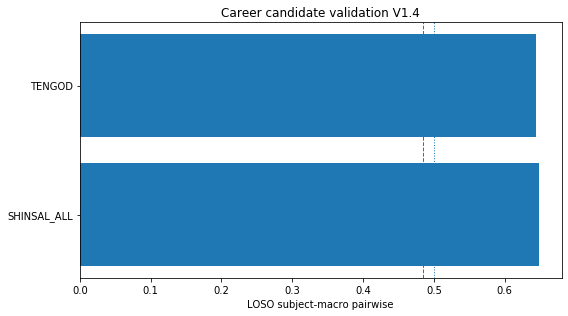

In [15]:
plot = candidate_summary.set_index("candidate")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot.index, plot["loso"])
ax.axvline(control_metrics["macro_pairwise"], linestyle="--", linewidth=1)
ax.axvline(0.5, linestyle=":", linewidth=1)
ax.set_xlabel("LOSO subject-macro pairwise")
ax.set_title("Career candidate validation V1.4")
plt.tight_layout()
plt.show()

# What to send back

After **Run All**, save the notebook and send:

```text
saju_ml_candidate_validation_v1_4.ipynb

research/ml/artifacts/v1_4/
├── FINAL_candidate_summary_v1_4.csv
├── FINAL_candidate_decision_v1_4.csv
├── candidate_repeated_cv_summary_v1_4.csv
├── candidate_loso_summary_v1_4.csv
├── candidate_permutation_summary_v1_4.csv
├── candidate_bootstrap_summary_v1_4.csv
├── tengod_coefficient_stability_v1_4.csv
├── shinsal_coefficient_stability_v1_4.csv
└── shinsal_attribution_v1_4.csv
```

The two most important files are:

1. `FINAL_candidate_summary_v1_4.csv`
2. `shinsal_attribution_v1_4.csv`